W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving datalab_에어컨키워드.xlsx to datalab_에어컨키워드.xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,월,검색량
0,2025-01-01,13.92186
1,2025-02-01,19.45531
2,2025-03-01,38.84443
3,2025-04-01,41.95696
4,2025-05-01,50.81964
5,2025-06-01,68.53754
6,2025-07-01,100.00000
7,2025-08-01,46.89311
8,2025-09-01,30.47667
9,2025-10-01,20.33445


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.2347
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - loss: 0.1701
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.1228
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0904
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.0742
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0764
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.0890
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0944
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0896
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0806
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0731
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0696
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0698
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0721
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0746
Epoch 16/300
1/1 ━━━

,월,검색량,실제값,LSTM 예측값
2,2025-03-01,38.84443,38.84443,35.769535
3,2025-04-01,41.95696,41.95696,44.097172
4,2025-05-01,50.81964,50.81964,47.809849
5,2025-06-01,68.53754,68.53754,71.254669
6,2025-07-01,100.00000,100.00000,99.432358
7,2025-08-01,46.89311,46.89311,47.165745
8,2025-09-01,30.47667,30.47667,30.458519
9,2025-10-01,20.33445,20.33445,21.123966
10,2025-11-01,10.24566,10.24566,8.806909
11,2025-12-01,9.05702,9.05702,12.337095


LSTM 예측 오차
MAE  : 1.7309
RMSE : 2.1054


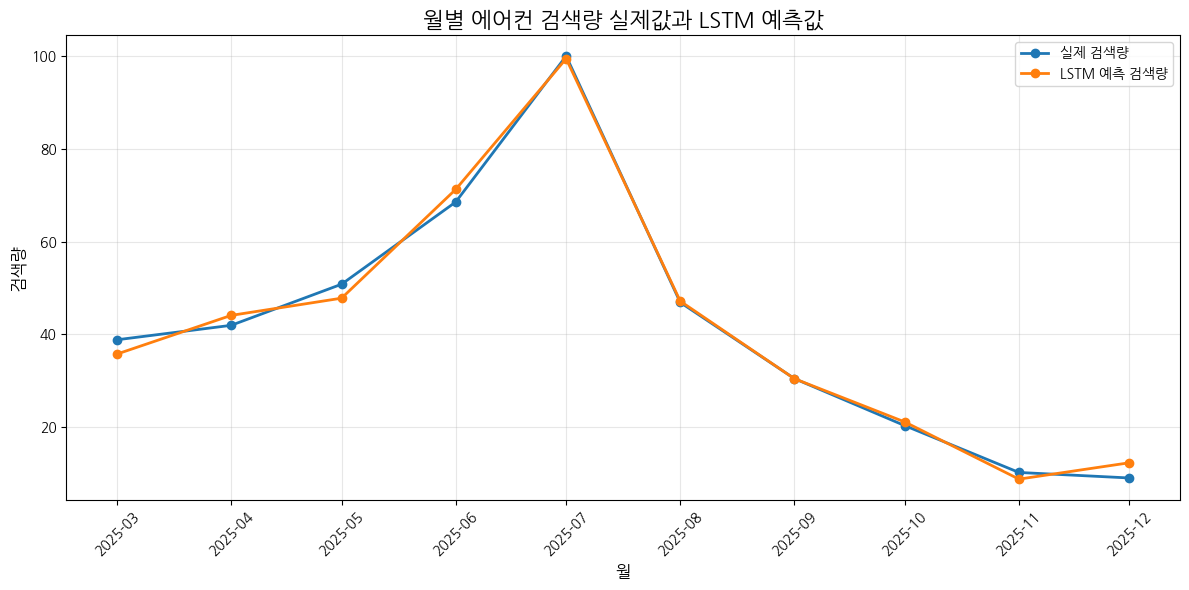

In [ ]:

# ============================================================
# 에어컨 검색량 LSTM 시계열 예측
# 학습 단위: 1
# Batch size: 100
# Window size: 2
# ============================================================

!pip install openpyxl -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

# ============================================================
# 한글 폰트 설정
# ============================================================

!apt-get update -qq
!apt-get install -qq fonts-nanum

fm._load_fontmanager(try_read_cache=False)
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

# ============================================================
# 1. 파일 업로드
# ============================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

raw = pd.read_excel(file_name, header=None)

# 네이버 데이터랩 형식 자동 처리
header_row = raw[raw.iloc[:, 0].astype(str).str.contains("날짜", na=False)].index[0]

df = raw.iloc[header_row + 1:].copy()
df.columns = ["월", "검색량"]

df["월"] = pd.to_datetime(df["월"])
df["검색량"] = pd.to_numeric(df["검색량"], errors="coerce")
df = df.dropna().reset_index(drop=True)

display(df)

# ============================================================
# 2. 데이터 정규화
# ============================================================

values = df[["검색량"]].values

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

# ============================================================
# 3. Window size = 2 데이터 생성
# ============================================================

window_size = 2

X, y = [], []

for i in range(len(scaled) - window_size):
    X.append(scaled[i:i + window_size])
    y.append(scaled[i + window_size])

X = np.array(X)
y = np.array(y)

# 학습 단위 1
X = X.reshape((X.shape[0], window_size, 1))

# ============================================================
# 4. LSTM 모델 생성
# ============================================================

model = Sequential()
model.add(LSTM(64, input_shape=(window_size, 1)))
model.add(Dense(1))

model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss="mse"
)

model.summary()

# ============================================================
# 5. 모델 학습
# Batch size = 100
# ============================================================

history = model.fit(
    X, y,
    epochs=300,
    batch_size=100,
    verbose=1
)

# ============================================================
# 6. 예측
# ============================================================

pred_scaled = model.predict(X)
pred = scaler.inverse_transform(pred_scaled)
actual = scaler.inverse_transform(y)

result = df.iloc[window_size:].copy()
result["실제값"] = actual.flatten()
result["LSTM 예측값"] = pred.flatten()

display(result)

# ============================================================
# 7. 예측 오차 계산
# ============================================================

mae = mean_absolute_error(result["실제값"], result["LSTM 예측값"])
rmse = np.sqrt(mean_squared_error(result["실제값"], result["LSTM 예측값"]))

print("=" * 50)
print("LSTM 예측 오차")
print("=" * 50)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

# ============================================================
# 8. 실제값 vs 예측값 시각화
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    result["월"],
    result["실제값"],
    marker="o",
    linewidth=2,
    label="실제 검색량"
)

plt.plot(
    result["월"],
    result["LSTM 예측값"],
    marker="o",
    linewidth=2,
    label="LSTM 예측 검색량"
)

plt.title("월별 에어컨 검색량 실제값과 LSTM 예측값", fontsize=16, fontweight="bold")
plt.xlabel("월", fontsize=12)
plt.ylabel("검색량", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()